# BTNet baseline (v2)

The same experiment as in `btnn-bs-torch-v1.ipynb`: fitting `BTNetEuropean` / `BTNetAmerican`, comparison with BS and Binomial Tree. 

In [1]:
import os

import numpy as np
import torch
from torchinfo import summary


## Import `btnn_bs`


In [2]:
from btnn_bs import (
    MyIBT_CRR,
    BTNetEuropean,
    BTNetAmerican,
    train_BTNet,
    bs_put_price,
    american_put_prices_binomial,
    plot_comparison,
    plot_errors,
    plot_training_losses,
    plot_prices_with_quantlib,
    plot_errors_vs_quantlib,
    run_quantlib_benchmark,
    error_stats,
    print_comparison_table,
)

## Initial Parameters 

In [3]:
# The paper parameters
S0 = 0.5
t0 = 0.0
T = 1.0
r = 0.05
sig = 0.25
n_dim = 9  # periods

# Train / test strikes
K_min, K_max = 0.25, 0.75
nK = 500

K_samples = np.random.uniform(K_min, K_max, nK).reshape(-1, 1)
K_test = np.linspace(K_min, K_max, 51).reshape(-1, 1)


## CRR Tree (`MyIBT_CRR`)


In [4]:
crr_tree = MyIBT_CRR(n=n_dim)

crr_tree.build(
    S0=S0,
    t0=t0,
    T=T,
    r=r,
    sigma=lambda S, t, teta: sig,
    teta=None,
)


## European Put — fit

In [5]:
prices_euro = bs_put_price(S0, K_samples, T, r, sig).reshape(-1, 1)

model_european = BTNetEuropean(n_dim, S0, sig, T, t0, r)

loss_hist_european = train_BTNet(
    model=model_european,
    K_train=K_samples,
    prices_train=prices_euro,
    epochs=200,
    lr=0.01,
)


train_BTNet:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch [50/200], Loss: 0.000003
Epoch [100/200], Loss: 0.000000
Epoch [150/200], Loss: 0.000000
Epoch [200/200], Loss: 0.000000


## European put — prediction and graphics


In [6]:
predictions_european = model_european.predict(K_test)
true_prices = bs_put_price(S0, K_test, T, r, sig)
crr_prices_european = np.array(
    [crr_tree.eval_european_put(float(K)) for K in K_test.flatten()]
)


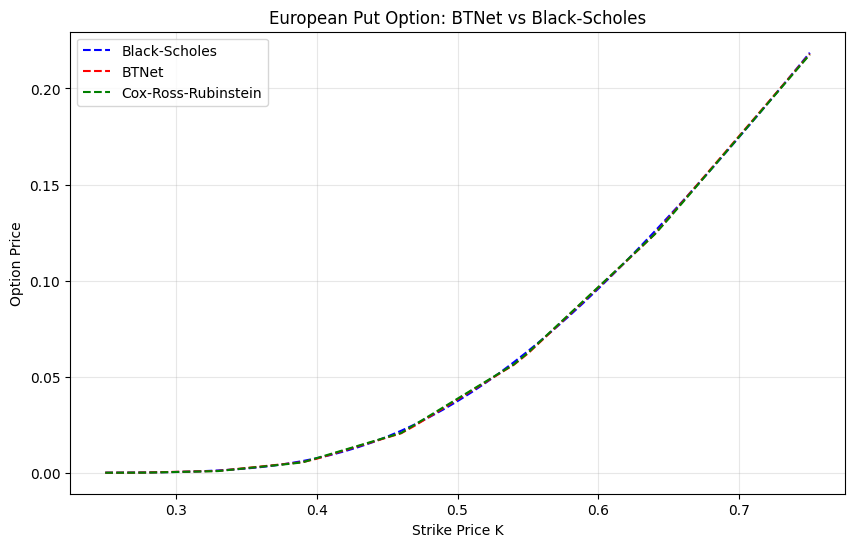

In [7]:
plot_comparison(
    K=K_test,
    bs_prices=true_prices,
    nn_prices=predictions_european,
    crr_prices=crr_prices_european,
    title="European Put Option: BTNet vs Black-Scholes",
)


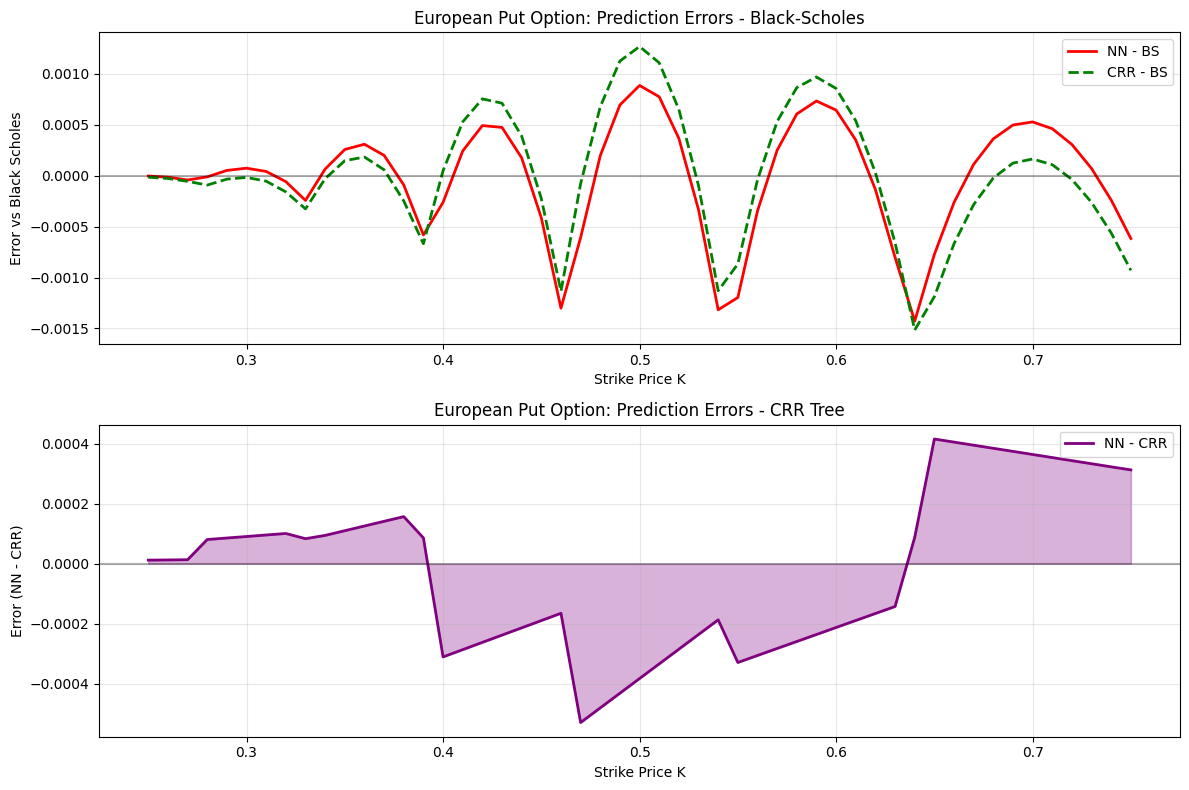

In [8]:
plot_errors(
    K=K_test,
    bs_prices=true_prices,
    nn_prices=predictions_european,
    crr_prices=crr_prices_european,
    title="European Put Option: Prediction Errors",
)


## American Put — fit


In [9]:
prices_american = np.array(
    [
        american_put_prices_binomial(
            S0=S0,
            K=float(K),
            T=T,
            r=r,
            sigma=sig,
            n=100,
        )
        for K in K_samples.flatten()
    ]
).reshape(-1, 1)


In [10]:
model_american = BTNetAmerican(
    n_dim=n_dim,
    S0=S0,
    sig=sig,
    T=T,
    t0=t0,
    r=r,
)

loss_hist_american = train_BTNet(
    model=model_american,
    K_train=K_samples,
    prices_train=prices_american,
    epochs=200,
    lr=0.01,
)


train_BTNet:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch [50/200], Loss: 0.000010
Epoch [100/200], Loss: 0.000005
Epoch [150/200], Loss: 0.000002
Epoch [200/200], Loss: 0.000001


## American Put — fit and graphics


In [11]:
predictions_american = model_american.predict(K_test).flatten()
true_prices_american = np.array(
    [
        american_put_prices_binomial(
            S0=S0,
            K=float(K),
            T=T,
            r=r,
            sigma=sig,
            n=100,
        )
        for K in K_test.flatten()
    ]
)
crr_prices_american = np.array(
    [crr_tree.eval_american_put(float(K)) for K in K_test.flatten()]
)


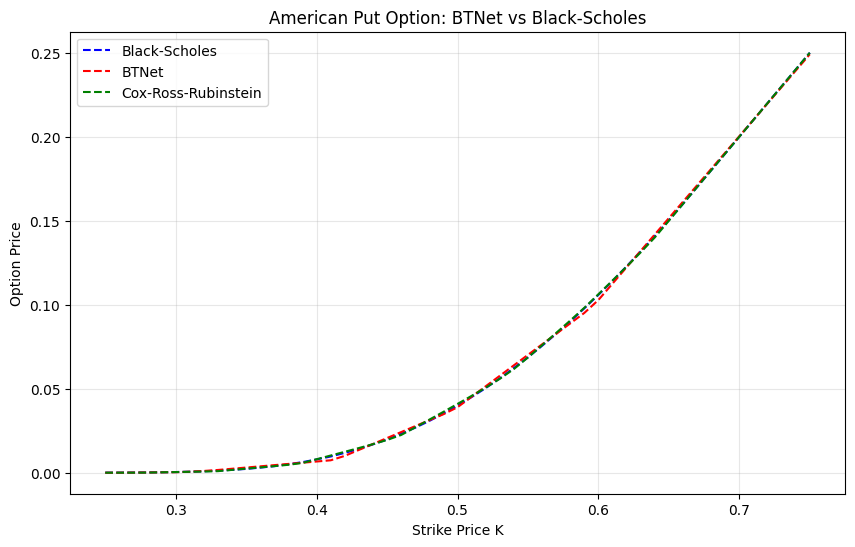

In [12]:
plot_comparison(
    K=K_test,
    bs_prices=true_prices_american,
    nn_prices=predictions_american,
    crr_prices=crr_prices_american,
    title="American Put Option: BTNet vs Black-Scholes",
)


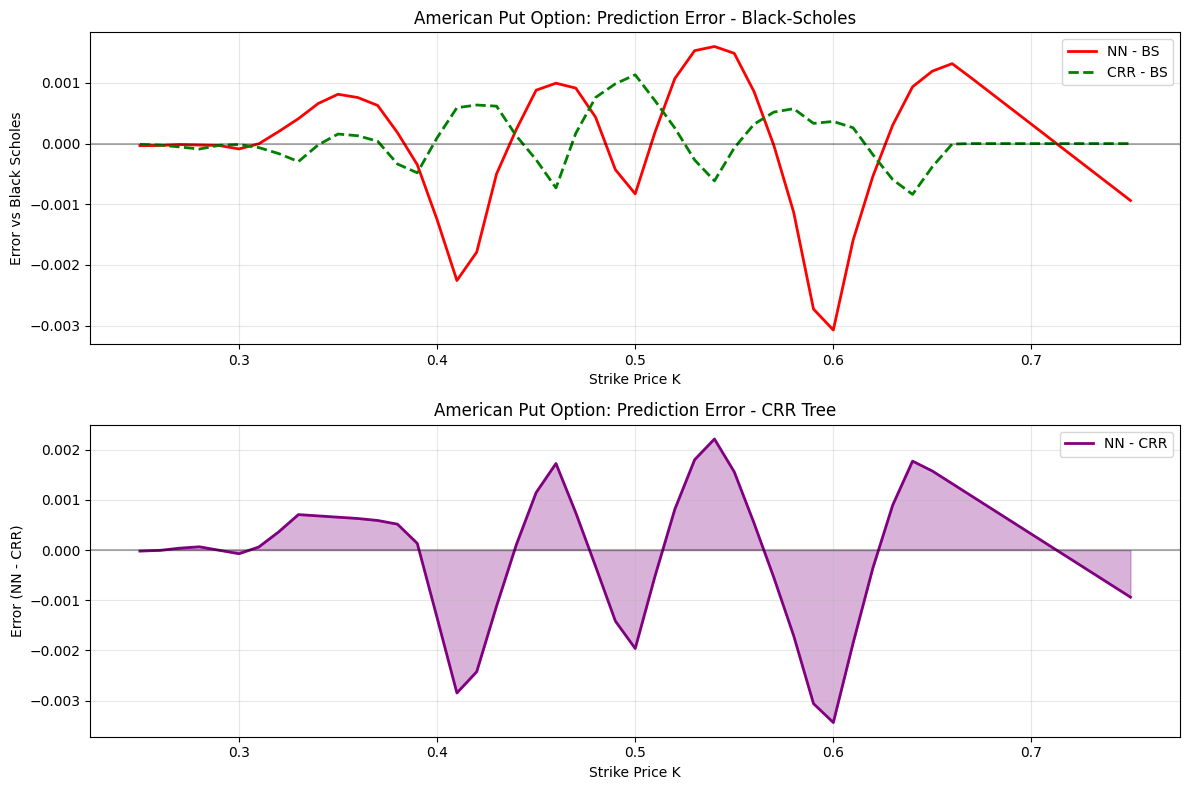

In [13]:
plot_errors(
    K=K_test,
    bs_prices=true_prices_american,
    nn_prices=predictions_american,
    crr_prices=crr_prices_american,
    title="American Put Option: Prediction Error",
)


## Verification according to the QuantLib

Independent prices: **European** — `AnalyticEuropeanEngine`; **American** — `BinomialVanillaEngine` (CRR) and if present — **BAW**.

In [14]:
QL_AMER_STEPS = 500

ql_res = run_quantlib_benchmark(
    S0,
    K_test,
    T,
    r,
    sig,
    amer_crr_steps=QL_AMER_STEPS,
    include_baw=True,
)

print("QuantLib evaluation date:", ql_res.ref_date)
print(
    f"Grid timing (s): EU analytic={ql_res.seconds_european_grid:.4f}, "
    f"US CRR ({ql_res.amer_crr_steps} steps)={ql_res.seconds_american_crr_grid:.4f}"
)
if ql_res.seconds_american_baw_grid is not None:
    print(f"US BAW grid timing (s): {ql_res.seconds_american_baw_grid:.4f}")


QuantLib evaluation date: January 1st, 2025
Grid timing (s): EU analytic=0.0078, US CRR (500 steps)=0.0309


In [15]:
euro_ql_metrics = {
    "NN − QL": error_stats(predictions_european, ql_res.ql_european_analytic),
    "BS − QL": error_stats(true_prices, ql_res.ql_european_analytic),
    "CRR − QL": error_stats(crr_prices_european, ql_res.ql_european_analytic),
}

amer_ql_metrics = {
    "NN − QL (CRR)": error_stats(predictions_american, ql_res.ql_american_crr),
    "numpy binom − QL": error_stats(true_prices_american, ql_res.ql_american_crr),
    "MyIBT − QL": error_stats(crr_prices_american, ql_res.ql_american_crr),
}
if ql_res.ql_american_baw is not None:
    amer_ql_metrics["NN − QL (BAW)"] = error_stats(
        predictions_american, ql_res.ql_american_baw
    )

print_comparison_table(european=euro_ql_metrics, american=amer_ql_metrics)


European put — errors vs QuantLib (analytic)
  NN − QL                 MAE=4.17e-04  RMSE=5.46e-04  max|.|=1.43e-03
  BS − QL                 MAE=4.33e-17  RMSE=5.75e-17  max|.|=1.67e-16
  CRR − QL                MAE=4.56e-04  RMSE=6.19e-04  max|.|=1.52e-03
American put — errors vs QuantLib (CRR tree)
  NN − QL (CRR)           MAE=7.78e-04  RMSE=1.03e-03  max|.|=3.04e-03
  numpy binom − QL        MAE=2.69e-05  RMSE=3.74e-05  max|.|=9.80e-05
  MyIBT − QL              MAE=2.88e-04  RMSE=4.13e-04  max|.|=1.09e-03


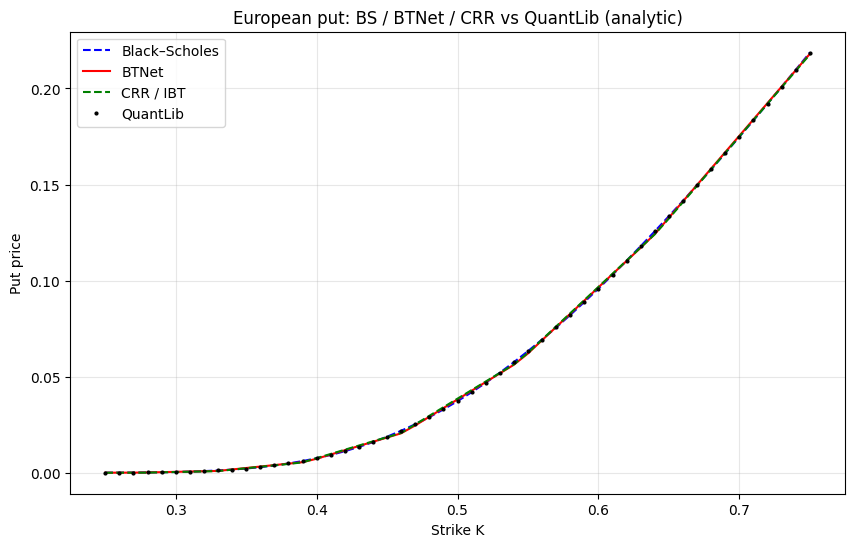

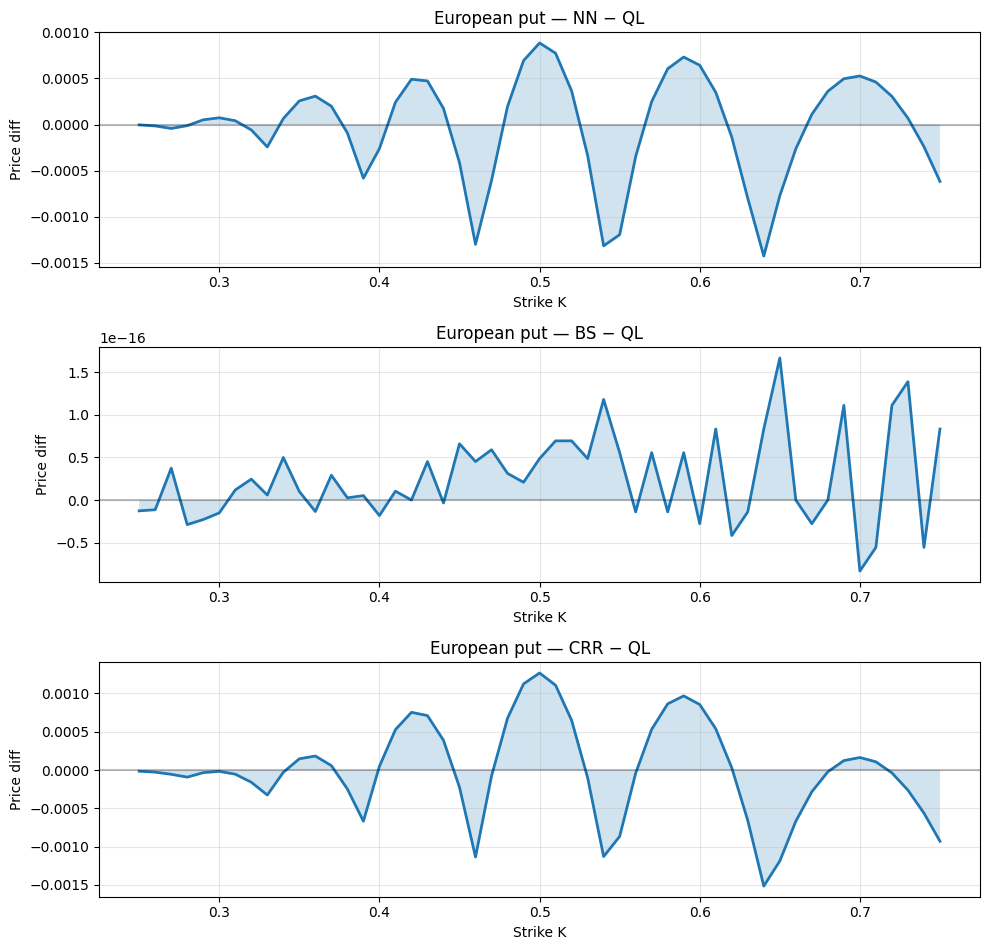

In [16]:
plot_prices_with_quantlib(
    K_test,
    true_prices,
    predictions_european,
    crr_prices_european,
    ql_res.ql_european_analytic,
    title="European put: BS / BTNet / CRR vs QuantLib (analytic)",
)

plot_errors_vs_quantlib(
    K_test,
    ql_res.ql_european_analytic,
    nn_prices=predictions_european,
    bs_prices=true_prices,
    crr_prices=crr_prices_european,
    title="European put",
)


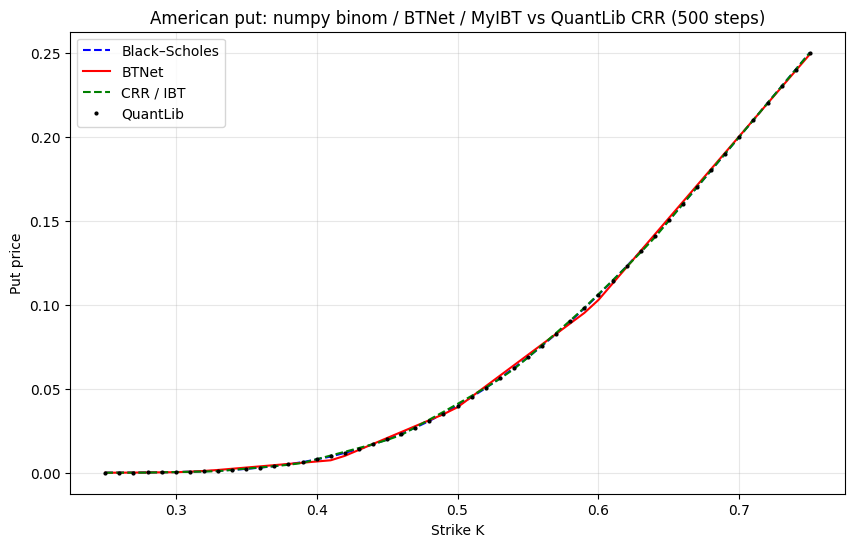

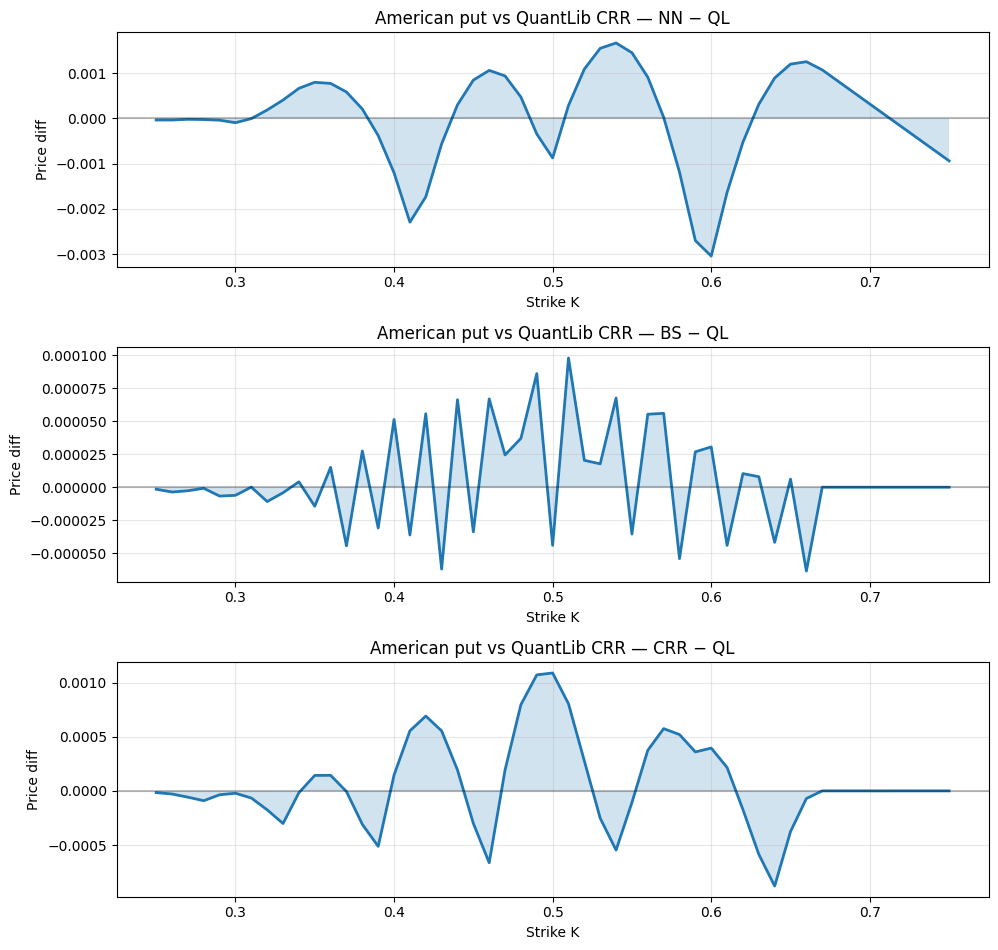

In [17]:
plot_prices_with_quantlib(
    K_test,
    true_prices_american,
    predictions_american,
    crr_prices_american,
    ql_res.ql_american_crr,
    title=f"American put: numpy binom / BTNet / MyIBT vs QuantLib CRR ({QL_AMER_STEPS} steps)",
)

plot_errors_vs_quantlib(
    K_test,
    ql_res.ql_american_crr,
    nn_prices=predictions_american,
    bs_prices=true_prices_american,
    crr_prices=crr_prices_american,
    title="American put vs QuantLib CRR",
)

if ql_res.ql_american_baw is not None:
    plot_prices_with_quantlib(
        K_test,
        true_prices_american,
        predictions_american,
        crr_prices_american,
        ql_res.ql_american_baw,
        title="American put: same models vs QuantLib BAW",
    )
    plot_errors_vs_quantlib(
        K_test,
        ql_res.ql_american_baw,
        nn_prices=predictions_american,
        bs_prices=true_prices_american,
        crr_prices=crr_prices_american,
        title="American put vs QuantLib BAW",
    )


## Losses of both BTNet's


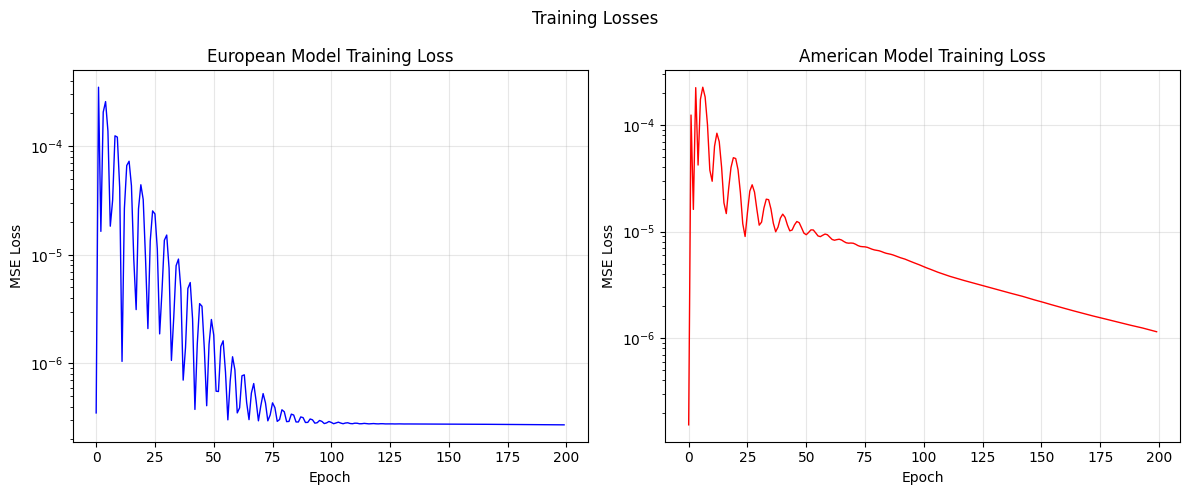

In [18]:
plot_training_losses(
    loss_hist_euro=loss_hist_european,
    loss_hist_amer=loss_hist_american,
)


## Analyze and Export to ONNX


In [19]:
base_path = "./outputs"
os.makedirs(base_path, exist_ok=True)


In [20]:
summary(model_european, input_size=(1, 1))


Layer (type:depth-idx)                   Output Shape              Param #
BTNetEuropean                            [1]                       --
├─DenseLayer: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 10]                   20
├─ConvLayer: 1-2                         [1, 9]                    --
│    └─Conv1d: 2-2                       [1, 1, 9]                 2
├─ConvLayer: 1-3                         [1, 8]                    (recursive)
│    └─Conv1d: 2-3                       [1, 1, 8]                 (recursive)
├─ConvLayer: 1-4                         [1, 7]                    (recursive)
│    └─Conv1d: 2-4                       [1, 1, 7]                 (recursive)
├─ConvLayer: 1-5                         [1, 6]                    (recursive)
│    └─Conv1d: 2-5                       [1, 1, 6]                 (recursive)
├─ConvLayer: 1-6                         [1, 5]                    (recursive)
│    └─Conv1d: 2-6     

In [21]:
torch.onnx.export(model_european, torch.randn(1, 1), f"{base_path}/model_european.onnx")


W0415 02:22:38.472000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0415 02:22:38.473000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0415 02:22:38.473000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 9 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"k"<FLOAT,[1,1]>
            ),
            outputs=(
                %"squeeze_9"<FLOAT,[1]>
            ),
            initializers=(
                %"_initial_layer._linear.weight"<FLOAT,[10,1]>{TorchTensor<FLOAT,[10,1]>(Parameter containing: tensor([[1.0031], [1.0001], [0.9976], [0.9960], [1.0113], [1.0001], [1.0010], [1.0000], [1.0000], [1.0000]], requires_grad=True), name='_initial_layer._linear.weight')},
                %"_initial_layer._linear.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.2298, -0.2745, -0.3293, -0.3913, -0.4670, -0.5442, -0.6394, -0.7584, -0.8960, -1.0585], requires_grad=True), name='_initial_layer._linear.bias')}

In [22]:
summary(model_american, input_size=(1, 1))


Layer (type:depth-idx)                   Output Shape              Param #
BTNetAmerican                            [1, 1]                    --
├─DenseLayer: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 10]                   20
├─ModuleList: 1-2                        --                        --
│    └─MaxoutLayer: 2-2                  [1, 9]                    --
│    │    └─Conv1d: 3-1                  [1, 1, 9]                 2
│    │    └─Linear: 3-2                  [1, 9]                    18
│    └─MaxoutLayer: 2-3                  [1, 8]                    --
│    │    └─Conv1d: 3-3                  [1, 1, 8]                 2
│    │    └─Linear: 3-4                  [1, 8]                    16
│    └─MaxoutLayer: 2-4                  [1, 7]                    --
│    │    └─Conv1d: 3-5                  [1, 1, 7]                 2
│    │    └─Linear: 3-6                  [1, 7]                    14
│    └─MaxoutLayer

In [23]:
torch.onnx.export(model_american, torch.randn(1, 1), f"{base_path}/model_american.onnx")


W0415 02:22:39.068000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0415 02:22:39.068000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0415 02:22:39.069000 23721 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 9 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"k"<FLOAT,[1,1]>
            ),
            outputs=(
                %"maximum_8"<FLOAT,[1,1]>
            ),
            initializers=(
                %"_initial_layer._linear.weight"<FLOAT,[10,1]>{TorchTensor<FLOAT,[10,1]>(Parameter containing: tensor([[1.0013], [0.9874], [0.9864], [0.9878], [0.9730], [0.9404], [0.9477], [1.0000], [1.0000], [1.0000]], requires_grad=True), name='_initial_layer._linear.weight')},
                %"_initial_layer._linear.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.2312, -0.3007, -0.3429, -0.4020, -0.4863, -0.6033, -0.6943, -0.7584, -0.8960, -1.0585], requires_grad=True), name='_initial_layer._linear.bias'